# Optimal Configuration Comparison

This notebook loads benchmark suite-result JSON files for a handful of named
configurations — typically the "optimal" configs recommended by the surrogate
model in `agent_eval_master_analysis.ipynb`, plus one or more baselines — and
creates one grouped 2×2 figure comparing:

1. Pass rate
2. Mean tokens per test
3. Total tokens
4. Average duration per test

**Every chart now shows two bars side by side for each configuration: its
result on the 53 standard optimization-suite tests, and its result on the
held-out validation suite** (tests never used during optimization). The
point is to see, per configuration, whether a gain on the standard suite
actually generalizes — a config that wins on the 53 standard tests but is
flat or worse on validation is telling you something different from one
that wins on both.

**Each configuration can have multiple repeated runs of each suite.** Point
the notebook at a *folder* of suite-result files per configuration per suite
(one file per run) and it will average across those runs automatically, with
the **95% confidence interval computed across the repeated runs** — not just
across the tests inside a single run. Concretely:

- For a configuration/suite pair with **2 or more runs**, each metric (pass
  rate, mean duration, mean/total tokens) is computed once per run, and the
  reported value is the mean of those per-run numbers, with a CI from the
  *run-to-run* spread (a t-distribution interval). This is the statistically
  appropriate way to combine repeated full-suite runs: all the tests inside
  one run share that run's conditions, so measuring spread only within a
  single run would understate the true uncertainty.
- For a configuration/suite pair with only **1 run** (no repeats available),
  there's no run-to-run spread to measure, so the CI instead comes from the
  spread across that run's individual test results (Wilson interval for the
  pass rate; a normal-approximation/bootstrap interval for the continuous
  metrics).

Every result table and chart below reports which basis applied (`ci_basis`:
`"across_run"` vs `"within_run"`), for both the standard and validation rows.
The bar charts also label each configuration with how many runs of each
suite went into it.

**This notebook shares its data loading, statistics, and plotting style with
`agent_eval_master_analysis.ipynb` and `framework_comparison.ipynb`** via
`agent_eval_core_master.py`, so colors, fonts, and uncertainty conventions
are the same across every notebook in this project. The standard-vs-validation
comparison is built on the same generic `test_set` grouping dimension that
`ae.plot_grouped_bars` already supports for any two-way split, not a
one-off for this notebook.

The notebook is set up so you can quickly tweak plotting options like figure
size, font size, bar labels, grid visibility, DPI, and whether to compare only
common test IDs (computed independently within each suite) or all tests.

> Edit `CONFIG_SOURCES` and `VALIDATION_SOURCES` in the next cell to point at your results.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import agent_eval_core_master_updated as ae

# ONE style call shared by every notebook in this project.
ae.set_publication_style() 

# Optional, used for the interactive controls near the bottom.
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
    print("ipywidgets is not available. The static plotting cells will still work.")


## 1. Point the notebook at your results

`CONFIG_SOURCES` maps each on-chart label to **where its standard-suite runs
live**; `VALIDATION_SOURCES` maps the *same* labels to where each
configuration's **held-out validation-suite runs** live. The two dicts must
use identical keys so each configuration's standard and validation bars line
up correctly — the loading cell below checks this and warns about any
mismatch.

Each value (in either dict) can be:

- a **directory** containing one suite-result `.json` (or `regression_data_*.jsonl`)
  file per run — the recommended setup when you have repeated runs to average
  over; every file inside is treated as one run of that configuration, and
  *all* of them are loaded and averaged,
- a **single file** (one run, no averaging), or
- an explicit **list** of files/directories, if your runs aren't all in one folder.

`labels` (the dict keys) control both the on-chart category labels and their
left-to-right order. `model_notes` is optional free-text per label, carried
through to the results table for your own documentation — it doesn't affect
any chart.


In [2]:
# Edit these paths as needed. Each entry is a LABEL -> WHERE ITS RUNS LIVE.
# CONFIG_SOURCES points at the 53 *standard* benchmark tests used to pick the
# optimal configs.
CONFIG_SOURCES = {
    "Optimal Config 1,\n2-Agents,\nPruned RAG": Path("./sweep_results/full_suite_optimal_configs/optimal_config_sonnet4_pruned_rag_two_agents/"),
    "Optimal Config 1,\n2-Agents,\nFull RAG":   Path("./sweep_results/full_suite_optimal_configs/optimal_config_sonnet4_no-pruned_two_agents/"),
    "Optimal Config 1 \n1-Agent,\n Pruned Rag": Path("./sweep_results/full_suite_optimal_configs/optimal_config_sonnet4_pruned_rag_one_agent/"),
    "Baseline Config,\nOne Agent,\nNo RAG":     Path("./sweep_results/full_suite_optimal_configs/baseline_one-agent_no-rag/"),
}

# SAME labels (keys must match CONFIG_SOURCES exactly), pointed at each
# configuration's held-out VALIDATION suite run(s) instead.
VALIDATION_SOURCES = {
    "Optimal Config 1,\n2-Agents,\nPruned RAG": Path("./sweep_results/full_suite_optimal_configs/optimal_config_sonnet4_pruned_rag_two_agent_validation/"),
    "Optimal Config 1,\n2-Agents,\nFull RAG":   Path("./sweep_results/full_suite_optimal_configs/optimal_config_sonnet4_no-pruned_rag_two_agent_validation/"),
    "Optimal Config 1 \n1-Agent,\n Pruned Rag": Path("./sweep_results/full_suite_optimal_configs/optimal_config_sonnet4_pruned_rag_one_agent_validation/"),
    "Baseline Config,\nOne Agent,\nNo RAG":     Path("./sweep_results/full_suite_optimal_configs/baseline_one_agent_no-rag_validation/"),
}

# Display names + left-to-right/legend order for the two test sets on every chart.
TEST_SET_LABELS = {"standard": "Standard (53 tests)", "validation": "Validation (held-out)"}
TEST_SET_ORDER = [TEST_SET_LABELS["standard"], TEST_SET_LABELS["validation"]]
TEST_SET_HATCHES = {TEST_SET_LABELS["standard"]: "///", TEST_SET_LABELS["validation"]: "xx"}

model_notes = {
    "Optimal Config 1,\n2-Agents,\nPruned RAG": "Sonnet 4, T=0.0, RAG Top K = 1",
    "Optimal Config 1,\n2-Agents,\nFull RAG":   "Sonnet 4, T=0.0, RAG Top K = 1",
    "Optimal Config 1,\n1-Agents,\nPruned RAG": "Sonnet 4, T=0.0, RAG Top K = 1",
    "Baseline Config,\nOne Agent,\nNo RAG":     "Sonnet 4, T=0.0, RAG Top K = 0",
}

for group_name, sources in [("standard", CONFIG_SOURCES), ("validation", VALIDATION_SOURCES)]:
    print(f"--- {TEST_SET_LABELS[group_name]} ---")
    for label, source in sources.items():
        source = Path(source)
        if source.is_dir():
            n_files = len(list(source.glob("suite_*.json"))) + len(list(source.glob("regression_data_*.jsonl")))
            print(f"{source}/  exists={source.exists()}  ({n_files} run file(s) found)")
        else:
            print(f"{source}  exists={source.exists()}  (1 run file)")
        print(f"    label={label!r:<45} notes={model_notes.get(label)!r}")

_missing = [l for l in CONFIG_SOURCES if l not in VALIDATION_SOURCES] + [l for l in VALIDATION_SOURCES if l not in CONFIG_SOURCES]
if _missing:
    print(f"\n⚠  Labels present in only one of CONFIG_SOURCES / VALIDATION_SOURCES "
          f"(that configuration will be missing a bar on one side of every chart): {_missing}")


--- Standard (53 tests) ---
sweep_results\full_suite_optimal_configs\optimal_config_sonnet4_pruned_rag_two_agents/  exists=True  (3 run file(s) found)
    label='Optimal Config 1,\n2-Agents,\nPruned RAG'    notes='Sonnet 4, T=0.0, RAG Top K = 1'
sweep_results\full_suite_optimal_configs\optimal_config_sonnet4_no-pruned_two_agents/  exists=True  (3 run file(s) found)
    label='Optimal Config 1,\n2-Agents,\nFull RAG'      notes='Sonnet 4, T=0.0, RAG Top K = 1'
sweep_results\full_suite_optimal_configs\optimal_config_sonnet4_pruned_rag_one_agent/  exists=True  (3 run file(s) found)
    label='Optimal Config 1 \n1-Agent,\n Pruned Rag'    notes=None
sweep_results\full_suite_optimal_configs\baseline_one-agent_no-rag/  exists=True  (3 run file(s) found)
    label='Baseline Config,\nOne Agent,\nNo RAG'        notes='Sonnet 4, T=0.0, RAG Top K = 0'
--- Validation (held-out) ---
sweep_results\full_suite_optimal_configs\optimal_config_sonnet4_pruned_rag_two_agent_validation/  exists=True  (6 run f

## 2. Data loading and summary

`ae.load_named_configs_multi` loads every run for every label **in both
`CONFIG_SOURCES` and `VALIDATION_SOURCES`**, using the same `suite_*.json` /
`regression_data_*.jsonl` parser used everywhere else in this project, tags
each individual test result with its config label, which run it came from,
**and which suite (`test_set`) it came from**. `ae.summarize_named_configs`
then computes the four headline metrics **per (configuration, test_set) pair**,
averaged across runs with a 95% CI on each one (across-run when there are
repeats, within-run when there is only one run — see the intro above),
optionally restricted to test IDs common to every configuration *within each
suite* (fairest comparison when suite sizes differ across configs — the
standard and validation suites' "common tests" are computed independently of
each other, since their test IDs are disjoint by design).


In [3]:
def summarize_suites(
    config_sources=CONFIG_SOURCES,
    validation_sources=VALIDATION_SOURCES,
    notes=model_notes,
    common_tests_only: bool = True,
) -> pd.DataFrame:
    '''
    Per-configuration benchmark summary, **for the standard suite and the
    validation suite side by side**, averaged across repeated runs of each.
    One row per (configuration, test_set) pair -- `test_set` is either
    "Standard (53 tests)" or "Validation (held-out)" -- with `plot_label`,
    `n_tests`, `pass_rate_percent`, `mean_tokens_per_test`, `total_tokens`,
    `mean_duration_seconds`, `<metric>_ci_low` / `<metric>_ci_high`,
    `n_runs`, and `ci_basis` exactly as in the single-suite version of this
    notebook (see the intro markdown cell for what across_run vs within_run
    means).

    `common_tests_only` restricts each test_set to the test_ids common to
    every configuration *within that test_set* -- the standard suite's and
    validation suite's "common tests" are computed independently, since
    their test_ids are disjoint by design.

    `notes` (optional, dict label -> string) is carried straight through to
    a `config_notes` column for documentation in the displayed table -- it
    does not affect any plot.
    '''
    runs = ae.load_named_configs_multi(
        {TEST_SET_LABELS["standard"]: config_sources, TEST_SET_LABELS["validation"]: validation_sources},
        label_col="plot_label", group_col="test_set",
    )
    if runs.empty:
        return pd.DataFrame()

    summary = ae.summarize_named_configs(
        runs, label_col="plot_label", group_col="test_set", common_tests_only=common_tests_only,
    )
    summary = summary.rename(columns={
        "mean_duration_s": "mean_duration_seconds",
        "mean_duration_s_ci_low": "mean_duration_seconds_ci_low",
        "mean_duration_s_ci_high": "mean_duration_seconds_ci_high",
    })
    summary["passed"] = (summary["pass_rate"] * summary["n_tests"]).round().astype(int)
    summary["failed_or_other"] = summary["n_tests"] - summary["passed"]

    # Config metadata (model/temperature) doesn't vary by test_set, so pull it
    # from either suite's rows -- one lookup per label, not per (label, test_set).
    cfg_info = runs.drop_duplicates("plot_label")[[c for c in ["plot_label", "cfg_llm_model", "cfg_llm_temperature"] if c in runs.columns]]
    cfg_info = cfg_info.rename(columns={"cfg_llm_model": "model", "cfg_llm_temperature": "temperature"})
    summary = summary.merge(cfg_info, on="plot_label", how="left")

    if notes:
        summary["config_notes"] = summary["plot_label"].map(notes)

    single_run = summary.loc[summary["n_runs"] <= 1, ["plot_label", "test_set"]]
    if len(single_run):
        pairs = [f"{row.plot_label.replace(chr(10), ' ')} / {row.test_set}" for row in single_run.itertuples()]
        print(f"⚠  Only one run found for: {pairs} "
              f"-- their CI comes from spread across tests within that one run, not run-to-run spread. "
              f"Point CONFIG_SOURCES/VALIDATION_SOURCES at a folder with more run files to average over repeats.")
    return summary


## 3. Plotting function

This function returns a single Matplotlib `Figure` containing all four
charts. Every panel is drawn with `ae.plot_grouped_bars` — the same
bar-with-error-bars primitive used in `framework_comparison.ipynb` — so
every bar in every panel necessarily carries its confidence interval.
**Each configuration is now drawn as two side-by-side sub-bars** (standard
suite vs. validation suite), colored by test set with a shared legend, and
each configuration's x-axis label is annotated with how many runs of each
suite it averages over.


In [4]:
def plot_benchmark_summary(
    summary: pd.DataFrame,
    *,
    title: str = "Benchmark Results: Standard Suite vs. Validation Suite",
    figsize: tuple[float, float] = (13.5, 8.5),
    dpi: int = 150,
    font_size: int = 11,
    title_size: int = 17,
    bar_width: float = 0.72,
    show_bar_labels: bool = True,
    show_grid: bool = True,
    grid_alpha: float = 0.25,
    ylim_padding: float = 0.16,
    rotate_xticks: int = 0,
    use_tight_layout: bool = True,
    show_run_counts: bool = True,
    color_map: dict | None = None,
    save_prefix: str | None = None,
) -> plt.Figure:
    '''
    Create one high-quality Matplotlib Figure containing all four bar charts,
    each with a 95% confidence interval.

    **Each configuration shows two side-by-side sub-bars**: its result on the
    53 standard optimization-suite tests, and its result on the held-out
    validation suite, so a gain on the standard suite that does or doesn't
    generalize is visible at a glance in every panel.

    Parameters mirror the single-suite version of `plot_benchmark_summary()`
    so the interactive controls below keep working unchanged. `color_map` is
    now keyed by *test set* ("Standard (53 tests)" / "Validation (held-out)")
    rather than by configuration -- color encodes which suite a bar belongs
    to, and every configuration shares the same two colors, with a legend.
    `show_run_counts` still appends "(std n=K, val n=K)" to each x-axis
    label so the reader can see how many repeated runs of each suite each
    configuration's intervals are based on.
    '''
    with plt.rc_context({
        "figure.dpi": dpi, "savefig.dpi": dpi, "font.size": font_size,
        "axes.titlesize": font_size + 2, "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 1, "ytick.labelsize": font_size - 1,
    }):
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=figsize, constrained_layout=use_tight_layout)

        category_order = (
            list(summary["plot_label"].cat.categories)
            if hasattr(summary["plot_label"], "cat") else list(dict.fromkeys(summary["plot_label"]))
        )
        group_order = [g for g in TEST_SET_ORDER if g in set(summary["test_set"])]
        cmap = color_map or ae.get_categorical_colors(group_order, palette=ae.BLUE_CMAP)

        # "Config Name (std n=3, val n=2)" run-count annotation per config.
        run_counts = summary.pivot_table(index="plot_label", columns="test_set", values="n_runs", aggfunc="first", observed=True)

        def _tick_label(lbl):
            if not show_run_counts:
                return lbl
            parts = []
            for g in group_order:
                n = run_counts.loc[lbl, g] if (lbl in run_counts.index and g in run_counts.columns and pd.notna(run_counts.loc[lbl, g])) else 0
                short = "std" if "Standard" in g else "val"
                parts.append(f"{short} n={int(n)}")
            return f"{lbl}\n({', '.join(parts)})"

        tick_labels = [_tick_label(lbl) for lbl in category_order]

        chart_specs = [
            (axes[0, 0], "pass_rate_percent", "Pass rate", "Pass rate (%)", lambda v: f"{v:.1f}%"),
            (axes[0, 1], "mean_tokens_per_test", "Mean tokens per test", "Tokens / test", lambda v: f"{v:,.0f}"),
            (axes[1, 0], "total_tokens", "Total tokens", "Total tokens", lambda v: f"{v:,.0f}"),
            (axes[1, 1], "mean_duration_seconds", "Average duration per test", "Seconds / test", lambda v: f"{v:.1f}s"),
        ]
        for ax, col, ttl, ylabel, fmt in chart_specs:
            s = summary.rename(columns={col: "estimate", f"{col}_ci_low": "ci_low", f"{col}_ci_high": "ci_high"})
            ae.plot_grouped_bars(
                ax, s, category_col="plot_label", category_order=category_order,
                group_col="test_set", group_order=group_order, color_map=cmap, hatch_map=TEST_SET_HATCHES,
                bar_label_fmt=(fmt if show_bar_labels else None), bar_label_fontsize=max(font_size - 1, 8),
                bar_width=bar_width, legend_title="Test set", show_legend=True,
                show_grid=show_grid, grid_alpha=grid_alpha,
                rotate_xticks=rotate_xticks, ylim_padding=ylim_padding,
            )
            ax.set_xticklabels(tick_labels, rotation=rotate_xticks, ha=("right" if rotate_xticks else "center"))
            ax.set_title(ttl, pad=10)
            ax.set_ylabel(ylabel)
            ax.set_axisbelow(True)

        fig.suptitle(title, fontsize=title_size, fontweight="bold")

        if save_prefix:
            ae.save_figure(fig, Path(save_prefix).name, Path(save_prefix).parent, formats=("png", "pdf", "svg"), dpi=dpi)

    return fig


## 4. Generate the default summary and figure


In [5]:
summary = summarize_suites(CONFIG_SOURCES, VALIDATION_SOURCES, notes=model_notes, common_tests_only=False)
summary.keys()


Index(['plot_label', 'test_set', 'n_runs', 'n_tests', 'ci_basis', 'pass_rate',
       'pass_rate_ci_low', 'pass_rate_ci_high', 'mean_duration_seconds',
       'mean_duration_seconds_ci_low', 'mean_duration_seconds_ci_high',
       'mean_tokens_per_test', 'mean_tokens_per_test_ci_low',
       'mean_tokens_per_test_ci_high', 'total_tokens', 'total_tokens_ci_low',
       'total_tokens_ci_high', 'total_estimated_cost',
       'total_estimated_cost_ci_low', 'total_estimated_cost_ci_high',
       'pass_rate_percent', 'pass_rate_percent_ci_low',
       'pass_rate_percent_ci_high', 'passed', 'failed_or_other', 'model',
       'temperature', 'config_notes'],
      dtype='object')

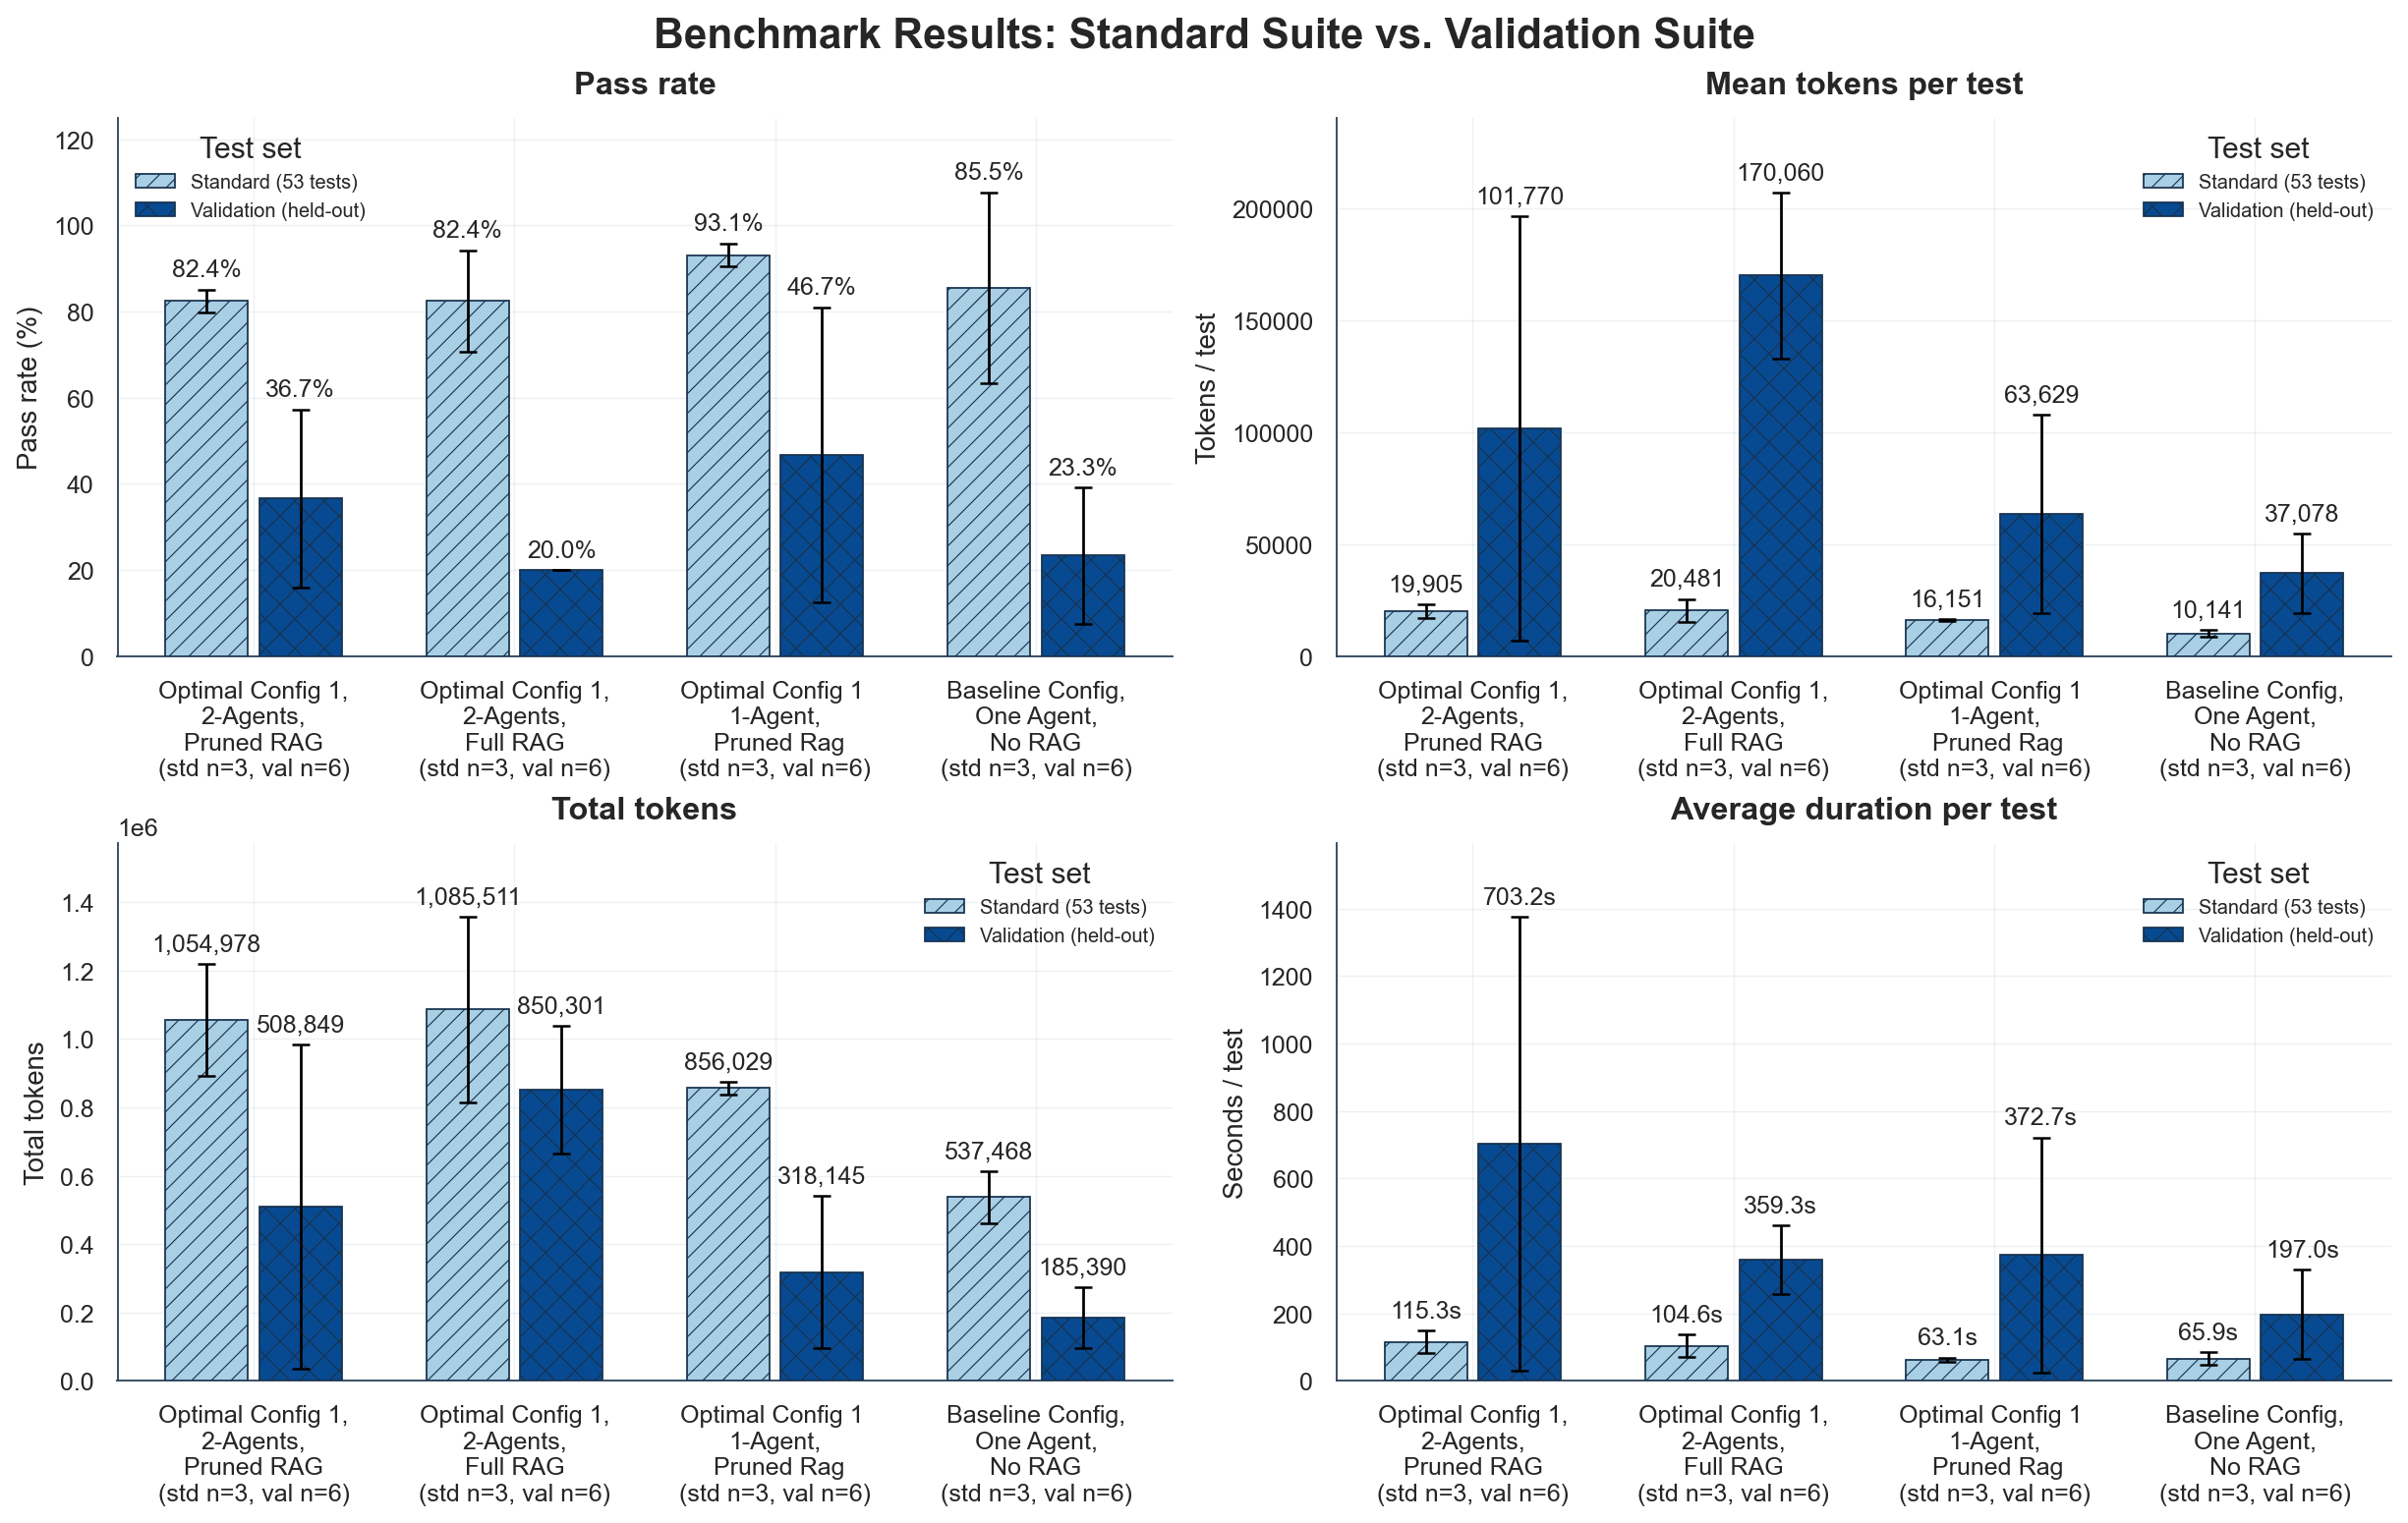

In [6]:
fig = plot_benchmark_summary(
    summary,
    figsize=(13.5, 8.5),
    dpi=180,
    font_size=11,
    title_size=17,
    save_prefix="./figures/optimal_suite_vs_validation_summary",
)
plt.show()


## 5. Interactive controls

Run this cell to get sliders and checkboxes for adjusting the plot. The
function redraws the single grouped figure (still via `ae.plot_grouped_bars`,
still with confidence intervals on every bar, still showing standard vs.
validation as side-by-side sub-bars) when controls change.


In [7]:
if HAS_WIDGETS:
    common_tests_only_widget = widgets.Checkbox(value=True, description="Common tests only", indent=False)
    show_bar_labels_widget = widgets.Checkbox(value=True, description="Show bar labels", indent=False)
    show_grid_widget = widgets.Checkbox(value=True, description="Show grid", indent=False)
    show_run_counts_widget = widgets.Checkbox(value=True, description="Show run counts", indent=False)
    width_widget = widgets.FloatSlider(value=13.5, min=8, max=20, step=0.5, description="Width", continuous_update=False)
    height_widget = widgets.FloatSlider(value=8.5, min=5, max=14, step=0.5, description="Height", continuous_update=False)
    dpi_widget = widgets.IntSlider(value=180, min=100, max=400, step=25, description="DPI", continuous_update=False)
    font_size_widget = widgets.IntSlider(value=11, min=8, max=18, step=1, description="Font size", continuous_update=False)
    title_size_widget = widgets.IntSlider(value=17, min=12, max=28, step=1, description="Title size", continuous_update=False)
    bar_width_widget = widgets.FloatSlider(value=0.72, min=0.3, max=1.0, step=0.02, description="Bar width", continuous_update=False)
    ylim_padding_widget = widgets.FloatSlider(value=0.16, min=0.02, max=0.5, step=0.02, description="Y padding", continuous_update=False)
    xtick_rotation_widget = widgets.IntSlider(value=0, min=0, max=90, step=5, description="X rotation", continuous_update=False)
    save_prefix_widget = widgets.Text(value="./figures/interactive_benchmark_summary", description="Save prefix")
    save_button = widgets.Button(description="Save current figure", button_style="success", icon="save")
    out = widgets.Output()

    current_fig = {"fig": None, "summary": None}

    def redraw(*_):
        with out:
            clear_output(wait=True)
            summary_i = summarize_suites(CONFIG_SOURCES, VALIDATION_SOURCES, notes=model_notes, common_tests_only=common_tests_only_widget.value)
            current_fig["summary"] = summary_i
            display(summary_i)
            fig_i = plot_benchmark_summary(
                summary_i,
                figsize=(width_widget.value, height_widget.value),
                dpi=dpi_widget.value,
                font_size=font_size_widget.value,
                title_size=title_size_widget.value,
                bar_width=bar_width_widget.value,
                show_bar_labels=show_bar_labels_widget.value,
                show_grid=show_grid_widget.value,
                show_run_counts=show_run_counts_widget.value,
                ylim_padding=ylim_padding_widget.value,
                rotate_xticks=xtick_rotation_widget.value,
            )
            current_fig["fig"] = fig_i
            plt.show()

    def save_current(_):
        with out:
            prefix = save_prefix_widget.value.strip() or "./figures/interactive_benchmark_summary"
            summary_i, fig_i = current_fig["summary"], current_fig["fig"]
            if summary_i is None or fig_i is None:
                redraw()
                summary_i, fig_i = current_fig["summary"], current_fig["fig"]
            Path(prefix).parent.mkdir(parents=True, exist_ok=True)
            summary_i.to_csv(f"{prefix}.csv", index=False)
            ae.save_figure(fig_i, Path(prefix).name, Path(prefix).parent, formats=("png", "pdf", "svg"), dpi=dpi_widget.value)
            print(f"Saved {prefix}.csv, {prefix}.png, {prefix}.pdf, and {prefix}.svg")

    controls = widgets.VBox([
        widgets.HBox([common_tests_only_widget, show_bar_labels_widget, show_grid_widget, show_run_counts_widget]),
        widgets.HBox([width_widget, height_widget, dpi_widget]),
        widgets.HBox([font_size_widget, title_size_widget, bar_width_widget]),
        widgets.HBox([ylim_padding_widget, xtick_rotation_widget]),
        widgets.HBox([save_prefix_widget, save_button]),
    ])

    for widget in [common_tests_only_widget, show_bar_labels_widget, show_grid_widget, show_run_counts_widget,
                   width_widget, height_widget, dpi_widget, font_size_widget, title_size_widget, bar_width_widget,
                   ylim_padding_widget, xtick_rotation_widget]:
        widget.observe(redraw, names="value")
    save_button.on_click(save_current)

    display(controls, out)
    redraw()
else:
    print("ipywidgets is not installed. Try: pip install ipywidgets")


Output()